In [ ]:
from typing import Optional
import graphviz

class Value():
    def __init__(self,data,children:Optional[list]=None
                          ,label:Optional[str]=None
                          ,operator:Optional[str]=None):
        self.data=data
        self.label=label
        self.grad=0
        self.children=children
        self.operator=operator
        self.backward=lambda:None
    
    def __add__(self,other):
        out=Value(self.data+other.data,children=(self,other),operator="+")
        def _backward():
            self.grad=1.0*out.grad
            other.grad=1.0*out.grad
        
        out.backward=_backward
        return out
    
    def __mul__(self,other):
        out=Value(self.data*other.data,children=(self,other),operator='*')
        def _backward():
            self.grad=other.data*out.grad
            other.grad=self.data*out.grad
        out.backward=_backward
        return out
    
    def backward(self):
        self
    
    def __repr__(self):
        return f"Value(data={self.data},grad={self.grad})"
    
    def printGraph(self):
        dot=graphviz.Digraph("test",node_attr={'shape': 'record'})

        dot.node(self.label,f'<f0> data:{self.data}|<f1> grad:{self.grad}')
        def printNode(node):
            if node.operator is not None:
                dot.node(node.operator,node.operator)
                dot.edge(node.operator,node.label)
                if node.children is not None:
                    for child in node.children:
                        dot.node(child.label,f'<f0> data:{child.data}|<f1> grad:{child.grad}')
                        dot.edge(child.label,node.operator)
                        printNode(child)
        
        printNode(self)

        return dot




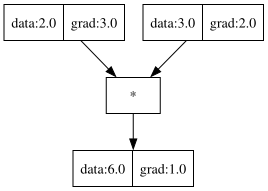

In [ ]:
a=Value(2.0,label='a')
b=Value(3.0,label='b')
c=Value(4.0,label='c')
d=Value(5.0,label='d')
ab=a*b
cd=c*d
e=ab+cd
e.grad=1.0
e.label='e'
e.backward()

e.printGraph()

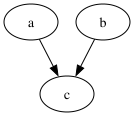

In [5]:
import graphviz

dot=graphviz.Digraph("test")

dot.node('a','a')
dot.node('b','b')
dot.node('c','c')

dot.edges(['ac','bc'])

dot